--- First 5 rows ---
   User ID    Device Model Operating System  App Usage Time (min/day)  \
0        1  Google Pixel 5          Android                       393   
1        2       OnePlus 9          Android                       268   
2        3    Xiaomi Mi 11          Android                       154   
3        4  Google Pixel 5          Android                       239   
4        5       iPhone 12              iOS                       187   

   Screen On Time (hours/day)  Battery Drain (mAh/day)  \
0                         6.4                     1872   
1                         4.7                     1331   
2                         4.0                      761   
3                         4.8                     1676   
4                         4.3                     1367   

   Number of Apps Installed  Data Usage (MB/day)  Age  Gender  \
0                        67                 1122   40    Male   
1                        42                  944   47  Female

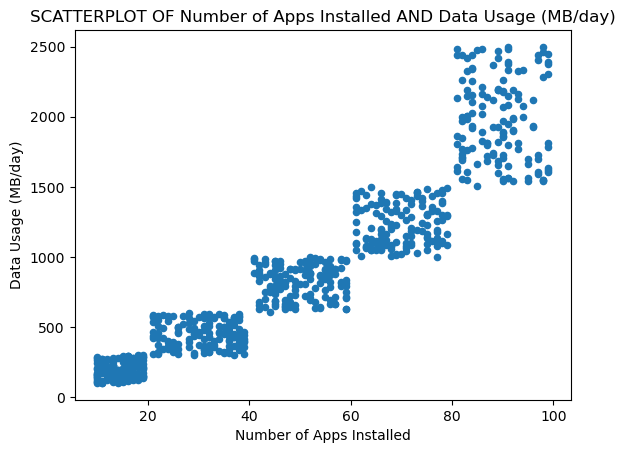


--- Data Types ---
User ID                         int64
Device Model                      str
Operating System                  str
App Usage Time (min/day)        int64
Screen On Time (hours/day)    float64
Battery Drain (mAh/day)         int64
Number of Apps Installed        int64
Data Usage (MB/day)             int64
Age                             int64
Gender                            str
User Behavior Class             int64
dtype: object

--- Correlation ---
0.9347999754105203

--- Descriptive Statistics ---
       Number of Apps Installed  Data Usage (MB/day)
count                700.000000           700.000000
mean                  50.681429           929.742857
std                   26.943324           640.451729
min                   10.000000           102.000000
25%                   26.000000           373.000000
50%                   49.000000           823.500000
75%                   74.000000          1341.000000
max                   99.000000          2497.000000

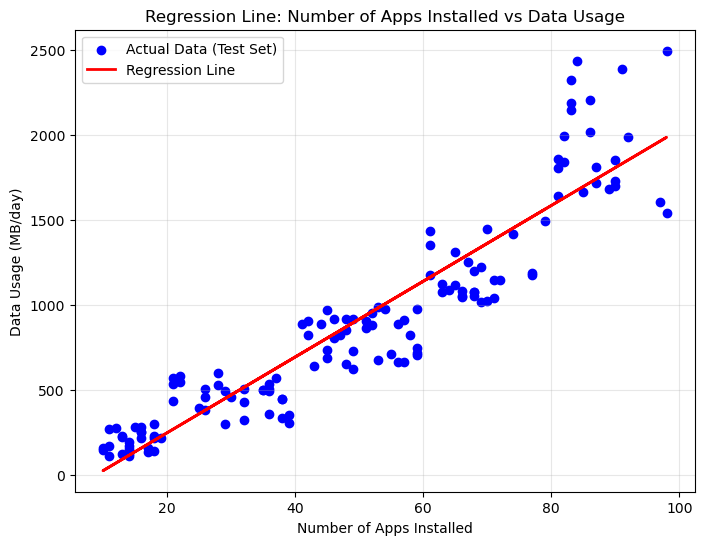

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
# 1. Loading and exploring the dataset
file_path = 'user_behavior_dataset.csv' 
df = pd.read_csv(file_path)
print("--- First 5 rows ---")
print(df.head())
print("\n--- Dataset Shape ---")
print(df.shape)
print("\n--- Scatterplot ---")
df.plot.scatter(x='Number of Apps Installed', y='Data Usage (MB/day)', title='SCATTERPLOT OF Number of Apps Installed AND Data Usage (MB/day)')
plt.show()
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Correlation ---")
print(df['Number of Apps Installed'].corr(df['Data Usage (MB/day)']))
print("\n--- Descriptive Statistics ---")
print(df[['Number of Apps Installed', 'Data Usage (MB/day)']].describe())
# Define Features (X) and Target (y)
X = df['Number of Apps Installed'].values.reshape(-1, 1)
y = df['Data Usage (MB/day)'].values.reshape(-1, 1)
# 2. Splitting the dataset into training and testing sets
SEED = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED) 
# 3. Training the linear regression model 
regressor = LinearRegression()
regressor.fit(X_train, y_train)
print("\n--- Model Parameters ---")
print("Intercept:", regressor.intercept_)
print("Coefficient:", regressor.coef_)
# Custom prediction function (Fixed missing '*' operator from original notebook)
def calc(slope, intercept, Number_of_Apps_Installed):
    return slope * Number_of_Apps_Installed + intercept
Data_Usage = calc(regressor.coef_, regressor.intercept_, 9.5)
print("\nPredicted Data Usage for 9.5 Apps Installed:", Data_Usage) 
# 4. Predicting and evaluating the model performance 
y_pred = regressor.predict(X_test)
df_preds = pd.DataFrame({'Actual': y_test.squeeze(), 'Predicted': y_pred.squeeze()})
print("\n--- Actual vs Predicted ---")
print(df_preds)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("\n--- Evaluation Metrics ---")
print(f'Mean absolute error: {mae:.2f}')
print(f'Mean squared error: {mse:.2f}')
print(f'Root mean squared error: {rmse:.2f}')
from sklearn.metrics import r2_score
print(f'R² Score: {r2_score(y_test, y_pred):.4f}') 
# 5. Plotting the regression line 
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data (Test Set)')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Regression Line: Number of Apps Installed vs Data Usage')
plt.xlabel('Number of Apps Installed')
plt.ylabel('Data Usage (MB/day)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()